In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('ai4i2020.csv')

In [ ]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [ ]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [ ]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
df = df.rename(columns={
        'Type': 'machine_type',
        'Air temperature [K]': 'air_temperature',
        'Process temperature [K]': 'process_temperature',
        'Rotational speed [rpm]': 'rotational_speed',
        'Torque [Nm]': 'torque',
        'Tool wear [min]': 'tool_wear',
        'Machine failure': 'target'
    })

df = df.drop(columns=['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], errors='ignore')

df = pd.get_dummies(df, columns=['machine_type'], prefix='machine_type', dtype=int)

df['temp_delta'] = df['process_temperature'] - df['air_temperature']
df['power_watts'] = df['torque'] * (df['rotational_speed'] * (2 * np.pi / 60))
df['overstrain_factor'] = df['tool_wear'] * df['torque']

In [ ]:
df.head()

,air_temperature,process_temperature,rotational_speed,torque,tool_wear,target,machine_type_H,machine_type_L,machine_type_M,temp_delta,power_watts,overstrain_factor
0,298.1,308.6,1551,42.8,0,0,0,0,1,10.5,6951.590560,0.0
1,298.2,308.7,1408,46.3,3,0,0,1,0,10.5,6826.722724,138.9
2,298.1,308.5,1498,49.4,5,0,0,1,0,10.4,7749.387543,247.0
3,298.2,308.6,1433,39.5,7,0,0,1,0,10.4,5927.504659,276.5
4,298.2,308.7,1408,40.0,9,0,0,1,0,10.5,5897.816608,360.0


In [ ]:
df.corr()

,air_temperature,process_temperature,rotational_speed,torque,tool_wear,target,machine_type_H,machine_type_L,machine_type_M,temp_delta,power_watts,overstrain_factor
air_temperature,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,-0.023025,0.006676,0.007958,-0.699583,-0.011474,0.006981
process_temperature,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,-0.017967,0.005564,0.005831,-0.268413,-0.010952,0.006003
rotational_speed,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,-0.001171,0.004735,-0.004296,-0.016727,-0.805584,-0.331277
torque,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,-0.004978,0.001191,0.001991,0.006690,0.978828,0.377038
tool_wear,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448,-0.002787,0.008232,-0.006976,-0.007689,-0.003193,0.897520
target,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000,-0.023916,0.035643,-0.022432,-0.111676,0.176039,0.190427
machine_type_H,-0.023025,-0.017967,-0.001171,-0.004978,-0.002787,-0.023916,1.000000,-0.408928,-0.218425,0.019377,-0.005061,-0.003993
machine_type_L,0.006676,0.005564,0.004735,0.001191,0.008232,0.035643,-0.408928,1.000000,-0.801211,-0.005094,0.003451,0.011618
machine_type_M,0.007958,0.005831,-0.004296,0.001991,-0.006976,-0.022432,-0.218425,-0.801211,1.000000,-0.007259,-0.000372,-0.009805
temp_delta,-0.699583,-0.268413,-0.016727,0.006690,-0.007689,-0.111676,0.019377,-0.005094,-0.007259,1.000000,0.006694,-0.005051


In [ ]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify =y, random_state = 42)


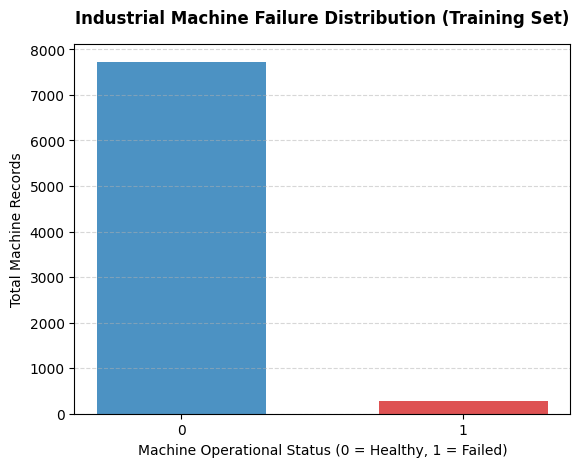

In [ ]:
status_counts = y_train.value_counts()
plt.bar(status_counts.index.astype(str), status_counts.values, color=['#1f77b4', '#d62728'], alpha=0.8, width=0.6)
plt.title("Industrial Machine Failure Distribution (Training Set)", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Machine Operational Status (0 = Healthy, 1 = Failed)", fontsize=10)
plt.ylabel("Total Machine Records", fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)


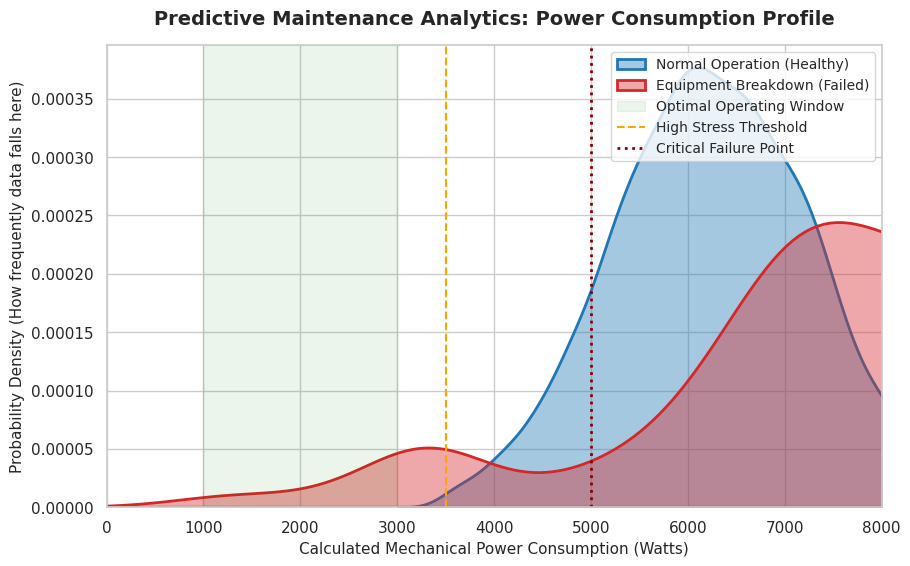

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set a professional, clean visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Plot the smooth distribution curves for Power Consumption
# We split the data by our target (0 = Healthy, 1 = Failed)
sns.kdeplot(data=X_train[y_train == 0], x='power_watts', label='Normal Operation (Healthy)', color='#1f77b4', fill=True, alpha=0.4, linewidth=2)
sns.kdeplot(data=X_train[y_train == 1], x='power_watts', label='Equipment Breakdown (Failed)', color='#d62728', fill=True, alpha=0.4, linewidth=2)

# 3. Add strategic engineering thresholds (Visualizing the Danger Zones)
# These are the mathematical sweet spots where machines start failing
plt.axvspan(1000, 3000, color='green', alpha=0.08, label='Optimal Operating Window')
plt.axvline(x=3500, color='orange', linestyle='--', linewidth=1.5, label='High Stress Threshold')
plt.axvline(x=5000, color='darkred', linestyle=':', linewidth=2, label='Critical Failure Point')

# 4. Premium Chart Styling
plt.title("Predictive Maintenance Analytics: Power Consumption Profile", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Calculated Mechanical Power Consumption (Watts)", fontsize=11)
plt.ylabel("Probability Density (How frequently data falls here)", fontsize=11)
plt.xlim(0, 8000) # Lock the X-axis limit to focus on the operational range
plt.legend(loc='upper right', fontsize=10)

# 5. Render the graph
plt.show()